# Preprocessing

**Dataset:** Mental Health and Lifestyle Habits (2019–2024)  
**Source:** https://www.kaggle.com/datasets/atharvasoundankar/mental-health-and-lifestyle-habits-2019-2024

---
## Content
1. Dataset Introduction
2. Variables Description
3. Data Preprocessing Steps
   - Load data
   - Meaning, check data type
   - Missing Values
   - Duplicates
   - Outliers
   - Categorical Encoding
   - Standardization / Normalization
4. Export Cleaned Dataset

## 0. Environment

In [77]:
# Install kagglehub to download dataset directly
!pip install kagglehub -q

In [78]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from scipy import stats
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from google.colab import userdata
import warnings
warnings.filterwarnings('ignore')

pat_token = userdata.get('PAT')

if not os.path.exists("/content/114-2-CE5033-Final-Project"):
    !git clone https://{pat_token}@github.com/1syuju/114-2-CE5033-Final-Project /content/114-2-CE5033-Final-Project

# Plot style
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')
print('All libraries loaded successfully!')

All libraries loaded successfully!


## 1. Dataset Introduction

**Mental Health and Lifestyle Habits (2019–2024)** is a dataset that records the relationship between lifestyle habits and mental health, with data collected from 2019 to 2024.

- **Purpose**: To explore how lifestyle habits such as sleep hours, exercise volume, and social media usage affect stress, anxiety, and depression indices.
- **Data Source**: Kaggle (public dataset)
- **Data Scale**: ≥ 1,500 records, ≥ 10 variables (meets course requirements)
- **Application Scenarios**: Mental health prediction, lifestyle improvement suggestions, public health analysis

In [79]:
# Load dataset from the GitHub repository
import pandas as pd
import os

repo_path = '/content/114-2-CE5033-Final-Project'
data_file_path = os.path.join(repo_path, 'data', 'Mental_Health_Lifestyle_Dataset.csv')

if os.path.exists(data_file_path):
    df_raw = pd.read_csv(data_file_path)
    print(f'Dataset loaded successfully from GitHub: {data_file_path}')
    print(f'Data shape: {df_raw.shape}')

# Display the first few rows of the loaded DataFrame
display(df_raw.head())

Dataset loaded successfully from GitHub: /content/114-2-CE5033-Final-Project/data/Mental_Health_Lifestyle_Dataset.csv
Data shape: (3000, 12)


,Country,Age,Gender,Exercise Level,Diet Type,Sleep Hours,Stress Level,Mental Health Condition,Work Hours per Week,Screen Time per Day (Hours),Social Interaction Score,Happiness Score
0,Brazil,48,Male,Low,Vegetarian,6.3,Low,NaN,21,4.0,7.8,6.5
1,Australia,31,Male,Moderate,Vegan,4.9,Low,PTSD,48,5.2,8.2,6.8
2,Japan,37,Female,Low,Vegetarian,7.2,High,NaN,43,4.7,9.6,9.7
3,Brazil,35,Male,Low,Vegan,7.2,Low,Depression,43,2.2,8.2,6.6
4,Germany,46,Male,Low,Balanced,7.3,Low,Anxiety,35,3.6,4.7,4.4


---
## 2. Variables Description

Including columns in dataset, data types, and meanings

In [80]:
print('=' * 60)
print('Basic Info')
print('=' * 60)
df_raw.info()

Basic Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 12 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Country                      3000 non-null   object 
 1   Age                          3000 non-null   int64  
 2   Gender                       3000 non-null   object 
 3   Exercise Level               3000 non-null   object 
 4   Diet Type                    3000 non-null   object 
 5   Sleep Hours                  3000 non-null   float64
 6   Stress Level                 3000 non-null   object 
 7   Mental Health Condition      2405 non-null   object 
 8   Work Hours per Week          3000 non-null   int64  
 9   Screen Time per Day (Hours)  3000 non-null   float64
 10  Social Interaction Score     3000 non-null   float64
 11  Happiness Score              3000 non-null   float64
dtypes: float64(4), int64(2), object(6)
memory usage: 281.4+ KB


In [81]:
col_summary = pd.DataFrame({
    'Column': df_raw.columns,
    'Dtype': df_raw.dtypes.values,
    'Non-Null Count': df_raw.notnull().sum().values,
    'Null Count': df_raw.isnull().sum().values,
    'Unique Values': df_raw.nunique().values,
    'Sample Values': [str(df_raw[c].dropna().unique()[:3].tolist()) for c in df_raw.columns]
})
print('\nColumn Summary：')
print(col_summary.to_string(index=False))


Column Summary：
                     Column   Dtype  Non-Null Count  Null Count  Unique Values                       Sample Values
                    Country  object            3000           0              7    ['Brazil', 'Australia', 'Japan']
                        Age   int64            3000           0             47                        [48, 31, 37]
                     Gender  object            3000           0              3         ['Male', 'Female', 'Other']
             Exercise Level  object            3000           0              3         ['Low', 'Moderate', 'High']
                  Diet Type  object            3000           0              5 ['Vegetarian', 'Vegan', 'Balanced']
                Sleep Hours float64            3000           0             93                     [6.3, 4.9, 7.2]
               Stress Level  object            3000           0              3         ['Low', 'High', 'Moderate']
    Mental Health Condition  object            2405         595

In [82]:
print('\nDescriptive Statistics：')
df_raw.describe().round(3)


Descriptive Statistics：


,Age,Sleep Hours,Work Hours per Week,Screen Time per Day (Hours),Social Interaction Score,Happiness Score
count,3000.000,3000.000,3000.000,3000.000,3000.000,3000.000
mean,41.230,6.476,39.466,5.090,5.470,5.395
std,13.428,1.500,11.451,1.747,2.564,2.558
min,18.000,1.400,20.000,2.000,1.000,1.000
25%,30.000,5.500,30.000,3.600,3.300,3.200
50%,41.000,6.500,39.000,5.100,5.500,5.400
75%,53.000,7.500,50.000,6.600,7.600,7.500
max,64.000,11.300,59.000,8.000,10.000,10.000


In [83]:
cat_cols = df_raw.select_dtypes(include=['object', 'category']).columns
print(f'categories：{list(cat_cols)}\n')
for col in cat_cols:
    print(f'--- {col} ---')
    print(df_raw[col].value_counts())
    print()

categories：['Country', 'Gender', 'Exercise Level', 'Diet Type', 'Stress Level', 'Mental Health Condition']

--- Country ---
Country
USA          446
Japan        439
Australia    434
India        434
Canada       428
Brazil       415
Germany      404
Name: count, dtype: int64

--- Gender ---
Gender
Female    1024
Other      996
Male       980
Name: count, dtype: int64

--- Exercise Level ---
Exercise Level
Low         1033
Moderate     998
High         969
Name: count, dtype: int64

--- Diet Type ---
Diet Type
Junk Food     637
Balanced      625
Vegetarian    592
Vegan         573
Keto          573
Name: count, dtype: int64

--- Stress Level ---
Stress Level
Low         1008
High        1002
Moderate     990
Name: count, dtype: int64

--- Mental Health Condition ---
Mental Health Condition
Anxiety       628
PTSD          624
Depression    580
Bipolar       573
Name: count, dtype: int64



---
## 3. Data Preprocessing Steps

### 3.1 Missing Values

In [84]:
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)

if len(missing_df) == 0:
    print('no missing value')
else:
    print(f'{len(missing_df)} missing values in total：')
    print(missing_df)

1 missing values in total：
                         Missing Count  Missing %
Mental Health Condition            595      19.83


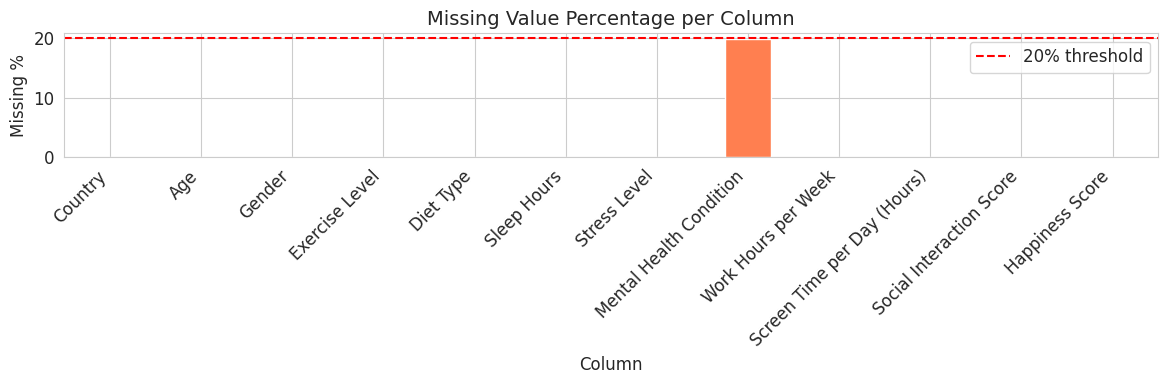

In [85]:
fig, ax = plt.subplots(figsize=(12, 4))
missing_pct_all = (df_raw.isnull().sum() / len(df_raw) * 100)
missing_pct_all.plot(kind='bar', color='coral', ax=ax)
ax.set_title('Missing Value Percentage per Column', fontsize=14)
ax.set_xlabel('Column')
ax.set_ylabel('Missing %')
ax.axhline(y=20, color='red', linestyle='--', label='20% threshold')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

In [86]:
# preserve original data
df = df_raw.copy()

num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

# use ME to fill val
for col in num_cols:
    n_missing = df[col].isnull().sum()
    if n_missing > 0:
        median_val = df[col].median()
        df[col].fillna(median_val, inplace=True)
        print(f'[Numeric] {col}: {n_missing} missing → ME {median_val:.2f}')

# use Mode to fill cat
for col in cat_cols:
    n_missing = df[col].isnull().sum()
    if n_missing > 0:
        mode_val = df[col].mode()[0]
        df[col].fillna(mode_val, inplace=True)
        print(f'[Categorical] {col}: {n_missing} missing → Mode "{mode_val}"')

print(f'\ntotal：{df.isnull().sum().sum()}')

[Categorical] Mental Health Condition: 595 missing → Mode "Anxiety"

total：0


### Duplicate Rows

In [87]:
n_dup = df.duplicated().sum()
print(f'number of duplicates：{n_dup} / {len(df)} ({n_dup/len(df)*100:.2f}%)')

if n_dup > 0:
    print('\ne.g.：')
    print(df[df.duplicated()].head())
    df.drop_duplicates(inplace=True)
    df.reset_index(drop=True, inplace=True)
    print(f'\nAfter removing duplicates, {len(df)} remain')
else:
    print('no dup')

number of duplicates：0 / 3000 (0.00%)
no dup


### 3.3 Outlier Detection

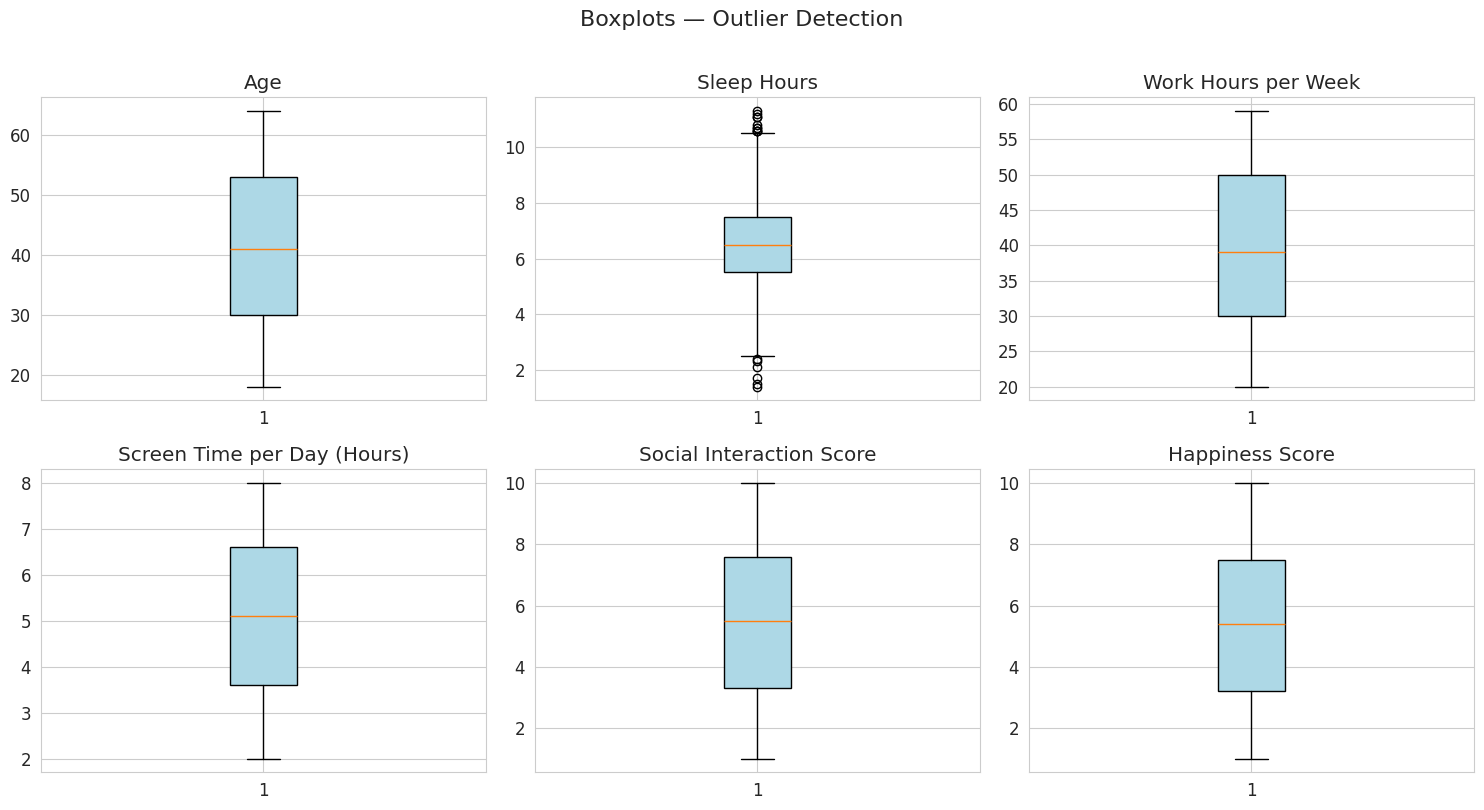

In [88]:
# Boxplot
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()

n_cols = 3
n_rows = int(np.ceil(len(num_cols) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].boxplot(df[col].dropna(), vert=True, patch_artist=True,
                    boxprops=dict(facecolor='lightblue'))
    axes[i].set_title(col)
    axes[i].set_xlabel('')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Boxplots — Outlier Detection', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

In [89]:
# IQR
print('IQR 法異常值統計：')
print(f'{"Column":<30} {"Outliers":>10} {"Outlier %":>10}')
print('-' * 52)
outlier_summary = {}
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    pct = n_out / len(df) * 100
    outlier_summary[col] = {'Q1': Q1, 'Q3': Q3, 'IQR': IQR,
                             'lower': lower, 'upper': upper, 'n_outliers': n_out}
    print(f'{col:<30} {n_out:>10} {pct:>9.2f}%')

IQR 法異常值統計：
Column                           Outliers  Outlier %
----------------------------------------------------
Age                                     0      0.00%
Sleep Hours                            16      0.53%
Work Hours per Week                     0      0.00%
Screen Time per Day (Hours)             0      0.00%
Social Interaction Score                0      0.00%
Happiness Score                         0      0.00%


In [90]:
# Winsorization
df_clean = df.copy()
for col in num_cols:
    lower = outlier_summary[col]['lower']
    upper = outlier_summary[col]['upper']
    n_before = ((df_clean[col] < lower) | (df_clean[col] > upper)).sum()
    df_clean[col] = df_clean[col].clip(lower=lower, upper=upper)
    if n_before > 0:
        print(f'{col}: Clipped {n_before} outliers → [{lower:.2f}, {upper:.2f}]')

print(f'\n Winsorization done, remain：{len(df_clean)}')

Sleep Hours: Clipped 16 outliers → [2.50, 10.50]

 Winsorization done, remain：3000


### 3.4 Categorical Encoding

In [91]:
# 3.4 Label Encoding & One-Hot Encoding
cat_cols = df_clean.select_dtypes(include=['object', 'category']).columns.tolist()
print(f'category：{cat_cols}\n')

df_encoded = df_clean.copy()
le = LabelEncoder()

# binary → Label Encoding
binary_cols = [c for c in cat_cols if df_clean[c].nunique() == 2]
# >=3 → One-Hot Encoding
multi_cols  = [c for c in cat_cols if df_clean[c].nunique() > 2]

print(f'Binary columns (Label Encoding): {binary_cols}')
for col in binary_cols:
    df_encoded[col + '_enc'] = le.fit_transform(df_encoded[col].astype(str))
    print(f'  {col}: {dict(zip(le.classes_, le.transform(le.classes_)))}')

print(f'\nMulti-category columns (One-Hot Encoding): {multi_cols}')
if multi_cols:
    df_encoded = pd.get_dummies(df_encoded, columns=multi_cols, drop_first=False)
    print(f'  After One-Hot encoding, add：{df_encoded.shape[1] - df_clean.shape[1]}')

print(f'\ndim：{df_encoded.shape}')

category：['Country', 'Gender', 'Exercise Level', 'Diet Type', 'Stress Level', 'Mental Health Condition']

Binary columns (Label Encoding): []

Multi-category columns (One-Hot Encoding): ['Country', 'Gender', 'Exercise Level', 'Diet Type', 'Stress Level', 'Mental Health Condition']
  After One-Hot encoding, add：19

dim：(3000, 31)


### 3.5 Standardization & Normalization

In [92]:
# 3.5 標準化
num_cols_final = df_clean.select_dtypes(include=[np.number]).columns.tolist()
print(f'Standardization & Normalization：{num_cols_final}\n')

# Z-score Standardization
scaler_std = StandardScaler()
df_standardized = df_clean.copy()
df_standardized[num_cols_final] = scaler_std.fit_transform(df_clean[num_cols_final])

# Min-Max Normalization
scaler_mm = MinMaxScaler()
df_normalized = df_clean.copy()
df_normalized[num_cols_final] = scaler_mm.fit_transform(df_clean[num_cols_final])

print('Z-score Standardization：')
print(df_standardized[num_cols_final[:3]].describe().round(3))

Standardization & Normalization：['Age', 'Sleep Hours', 'Work Hours per Week', 'Screen Time per Day (Hours)', 'Social Interaction Score', 'Happiness Score']

Z-score Standardization：
            Age  Sleep Hours  Work Hours per Week
count  3000.000     3000.000             3000.000
mean      0.000        0.000                0.000
std       1.000        1.000                1.000
min      -1.730       -2.664               -1.700
25%      -0.836       -0.654               -0.827
50%      -0.017        0.016               -0.041
75%       0.877        0.686                0.920
max       1.696        2.696                1.706


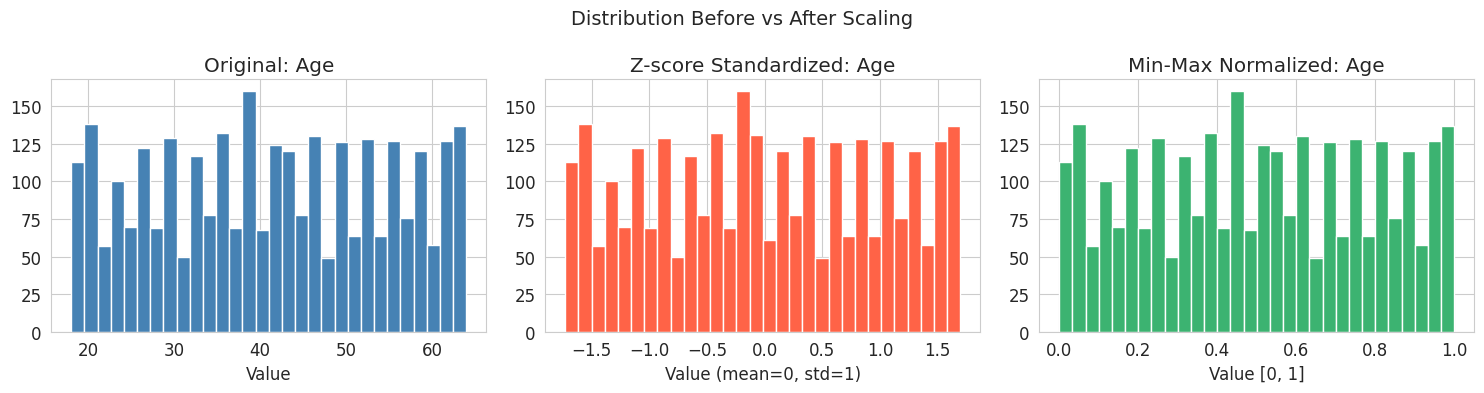

In [93]:
demo_col = num_cols_final[0]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(df_clean[demo_col], bins=30, color='steelblue', edgecolor='white')
axes[0].set_title(f'Original: {demo_col}')
axes[0].set_xlabel('Value')

axes[1].hist(df_standardized[demo_col], bins=30, color='tomato', edgecolor='white')
axes[1].set_title(f'Z-score Standardized: {demo_col}')
axes[1].set_xlabel('Value (mean=0, std=1)')

axes[2].hist(df_normalized[demo_col], bins=30, color='mediumseagreen', edgecolor='white')
axes[2].set_title(f'Min-Max Normalized: {demo_col}')
axes[2].set_xlabel('Value [0, 1]')

plt.suptitle('Distribution Before vs After Scaling', fontsize=14)
plt.tight_layout()
plt.show()

---
## 4. Data Quality Summary & Preprocessing Review

In [94]:
# 4.1 Comparison Before & After Preprocessing
print('=' * 55)
print('  Data Preprocessing Comparison (Data Quality Summary)')
print('=' * 55)
print(f'{'Item':<25} {'Before':>12} {'After':>12}')
print('-' * 55)
print(f'{'Number of Rows':<25} {df_raw.shape[0]:>12} {df_clean.shape[0]:>12}')
print(f'{'Number of Columns':<25} {df_raw.shape[1]:>12} {df_clean.shape[1]:>12}')
print(f'{'Total Missing Values':<25} {df_raw.isnull().sum().sum():>12} {df_clean.isnull().sum().sum():>12}')
print(f'{'Number of Duplicates':<25} {df_raw.duplicated().sum():>12} {df_clean.duplicated().sum():>12}')
print('=' * 55)
print()
print('Summary of Processing Steps:')
print('  1. Missing Values → Numeric columns imputed with median; Categorical columns with mode')
print('  2. Duplicates → Duplicate rows removed')
print('  3. Outliers → Detected by IQR method, Winsorization used to clip values to bounds')
print('  4. Categorical Encoding → Binary columns Label Encoded; Multi-category One-Hot Encoded')
print('  5. Numerical Standardization → Both Z-score & Min-Max versions retained')

  Data Preprocessing Comparison (Data Quality Summary)
Item                            Before        After
-------------------------------------------------------
Number of Rows                    3000         3000
Number of Columns                   12           12
Total Missing Values               595            0
Number of Duplicates                 0            0

Summary of Processing Steps:
  1. Missing Values → Numeric columns imputed with median; Categorical columns with mode
  2. Duplicates → Duplicate rows removed
  3. Outliers → Detected by IQR method, Winsorization used to clip values to bounds
  4. Categorical Encoding → Binary columns Label Encoded; Multi-category One-Hot Encoded
  5. Numerical Standardization → Both Z-score & Min-Max versions retained


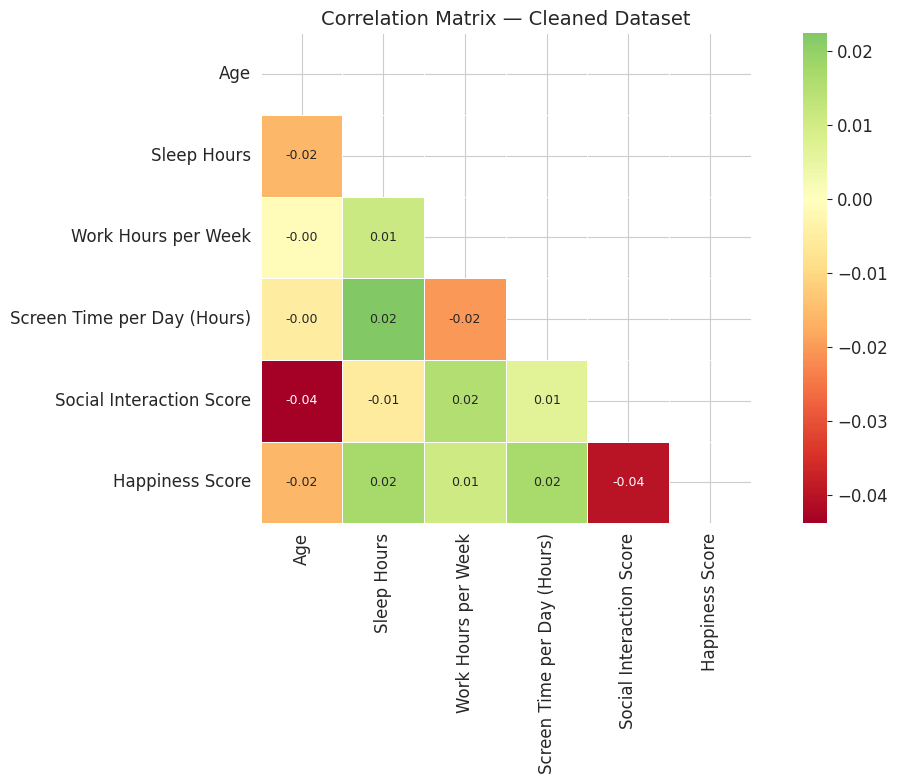

In [95]:
# 4.2 Heatmap
num_cols_final = df_clean.select_dtypes(include=[np.number]).columns
corr = df_clean[num_cols_final].corr()

plt.figure(figsize=(12, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            mask=mask, center=0,
            linewidths=0.5, square=True,
            annot_kws={'size': 9})
plt.title('Correlation Matrix — Cleaned Dataset', fontsize=14)
plt.tight_layout()
plt.show()

---
## 5. Cleaned Dataset

In [96]:
df_clean.to_csv('cleaned_data.csv', index=False)
df_standardized.to_csv('cleaned_data_std.csv', index=False)

print('Exported the following files:')
print(' cleaned_data.csv     — Cleaned raw-scale data (for EDA & visualization)')
print(' cleaned_data_std.csv — Z-score standardized version (for ML model use)')
print(f'\nFinal data dimensions: {df_clean.shape}')
df_clean.head()

Exported the following files:
 cleaned_data.csv     — Cleaned raw-scale data (for EDA & visualization)
 cleaned_data_std.csv — Z-score standardized version (for ML model use)

Final data dimensions: (3000, 12)


,Country,Age,Gender,Exercise Level,Diet Type,Sleep Hours,Stress Level,Mental Health Condition,Work Hours per Week,Screen Time per Day (Hours),Social Interaction Score,Happiness Score
0,Brazil,48,Male,Low,Vegetarian,6.3,Low,Anxiety,21,4.0,7.8,6.5
1,Australia,31,Male,Moderate,Vegan,4.9,Low,PTSD,48,5.2,8.2,6.8
2,Japan,37,Female,Low,Vegetarian,7.2,High,Anxiety,43,4.7,9.6,9.7
3,Brazil,35,Male,Low,Vegan,7.2,Low,Depression,43,2.2,8.2,6.6
4,Germany,46,Male,Low,Balanced,7.3,Low,Anxiety,35,3.6,4.7,4.4
